In [49]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
INPUT_XLSX   = "process_data_3.xlsx"
EMB_NPY      = "embeddings_resnet50.npy"
PATHS_JSON   = "image_paths.json"
OUTPUT_XLSX  = "process_data_4.xlsx"
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
PCA_VAR      = 0.95     # giữ >=95% variance
TSNE_MAX_N   = 2000

In [51]:
df = pd.read_excel(INPUT_XLSX)
assert "path" in df.columns, f"{INPUT_XLSX} thiếu cột 'path'!"
all_paths = df["path"].astype(str).tolist()
exists_mask = [os.path.exists(p) for p in all_paths]
paths_valid = [p for p, ok in zip(all_paths, exists_mask) if ok]
print(f"✅ Ảnh tồn tại: {len(paths_valid)}/{len(all_paths)}")
if not paths_valid:
    raise ValueError("Không có ảnh hợp lệ để trích xuất đặc trưng!")

✅ Ảnh tồn tại: 500/500


In [52]:
skip_extract = os.path.exists(EMB_NPY) and os.path.exists(PATHS_JSON)
print(f"⏭️  Bỏ qua trích xuất? {skip_extract}")

if not skip_extract:
    import tensorflow as tf
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input

    def load_and_preprocess(p):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img

    ds = tf.data.Dataset.from_tensor_slices(paths_valid)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print("🔄 Load ResNet50 (ImageNet, pooling=avg)...")
    base = ResNet50(weights="imagenet", include_top=False, pooling="avg")
    embs = []
    for i, batch in enumerate(ds):
        if i % 10 == 0:
            print(f"   batch {i} ...")
        feat = base(batch, training=False).numpy()
        feat = feat / (np.linalg.norm(feat, axis=1, keepdims=True) + 1e-8)
        embs.append(feat)

    embeddings = np.concatenate(embs, axis=0)
    np.save(EMB_NPY, embeddings)
    with open(PATHS_JSON, "w", encoding="utf-8") as f:
        json.dump(paths_valid, f, ensure_ascii=False)
    print(f"✅ Saved embeddings: {EMB_NPY} shape={embeddings.shape}")
else:
    embeddings = np.load(EMB_NPY)
    with open(PATHS_JSON, "r") as f:
        paths_valid = json.load(f)
    print(f"📦 Dùng lại embeddings: {embeddings.shape}")

⏭️  Bỏ qua trích xuất? True
📦 Dùng lại embeddings: (500, 2048)


In [53]:
skip_extract = os.path.exists(EMB_NPY) and os.path.exists(PATHS_JSON)
print(f"⏭️  Bỏ qua trích xuất? {skip_extract}")

if not skip_extract:
    import tensorflow as tf
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input

    def load_and_preprocess(p):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img

    ds = tf.data.Dataset.from_tensor_slices(paths_valid)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print("🔄 Load ResNet50 (ImageNet, pooling=avg)...")
    base = ResNet50(weights="imagenet", include_top=False, pooling="avg")
    embs = []
    for i, batch in enumerate(ds):
        if i % 10 == 0:
            print(f"   batch {i} ...")
        feat = base(batch, training=False).numpy()
        feat = feat / (np.linalg.norm(feat, axis=1, keepdims=True) + 1e-8)
        embs.append(feat)

    embeddings = np.concatenate(embs, axis=0)
    np.save(EMB_NPY, embeddings)
    with open(PATHS_JSON, "w", encoding="utf-8") as f:
        json.dump(paths_valid, f, ensure_ascii=False)
    print(f"✅ Saved embeddings: {EMB_NPY} shape={embeddings.shape}")
else:
    embeddings = np.load(EMB_NPY)
    with open(PATHS_JSON, "r") as f:
        paths_valid = json.load(f)
    print(f"📦 Dùng lại embeddings: {embeddings.shape}")


⏭️  Bỏ qua trích xuất? True
📦 Dùng lại embeddings: (500, 2048)


In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=PCA_VAR, svd_solver="full", random_state=42)
emb_pca = pca.fit_transform(embeddings)
print(f"✅ PCA: {embeddings.shape[1]} → {emb_pca.shape[1]} chiều | Explained variance = {pca.explained_variance_ratio_.sum()*100:.2f}%")

✅ PCA: 2048 → 216 chiều | Explained variance = 95.03%


In [55]:
pca_cols = [f"pca_{i+1}" for i in range(emb_pca.shape[1])]
df_pca = pd.DataFrame(emb_pca, columns=pca_cols)
df_pca.insert(0, "path", paths_valid)

# Merge vào df gốc theo path
df_out = df.merge(df_pca, on="path", how="left")

# Lưu ra Excel mới
df_out.to_excel(OUTPUT_XLSX, index=False)
print(f"💾 Saved full dataset with PCA features → {OUTPUT_XLSX} | shape={df_out.shape}")

💾 Saved full dataset with PCA features → process_data_4.xlsx | shape=(500, 229)


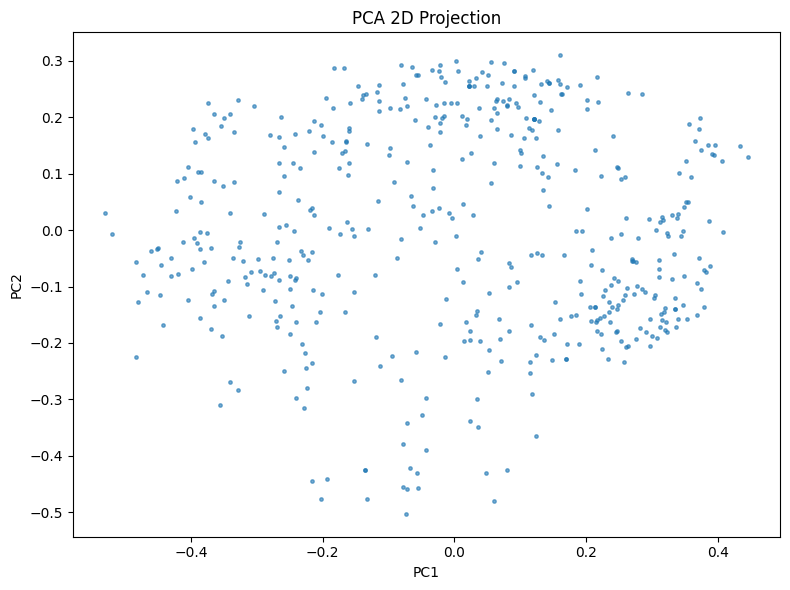

🖼️ Saved: pca_scatter_2d.png


In [56]:
if emb_pca.shape[1] >= 2:
    plt.figure(figsize=(8,6))
    plt.scatter(emb_pca[:,0], emb_pca[:,1], s=6, alpha=0.6)
    plt.title("PCA 2D Projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig("pca_scatter_2d.png", dpi=160)
    plt.show()
    print("🖼️ Saved: pca_scatter_2d.png")

⏳ t-SNE on 500 samples ...


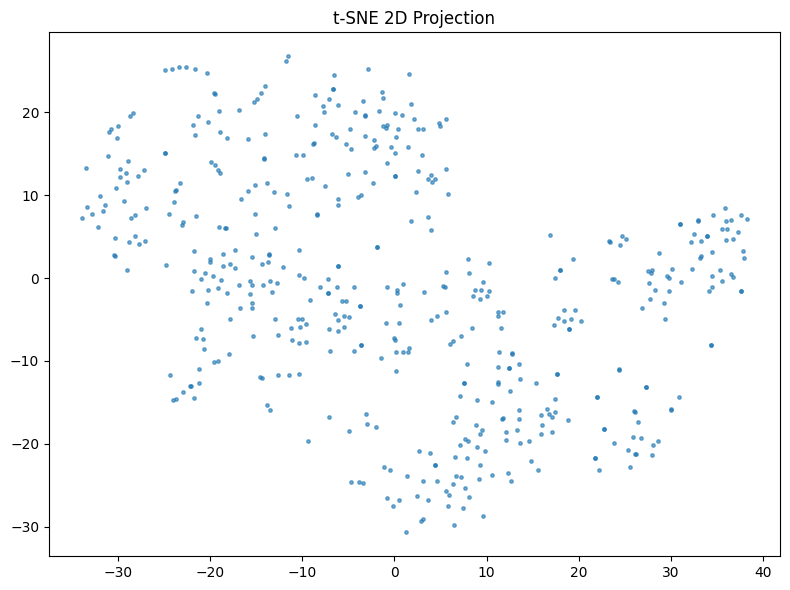

🖼️ Saved: tsne_scatter_2d.png


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


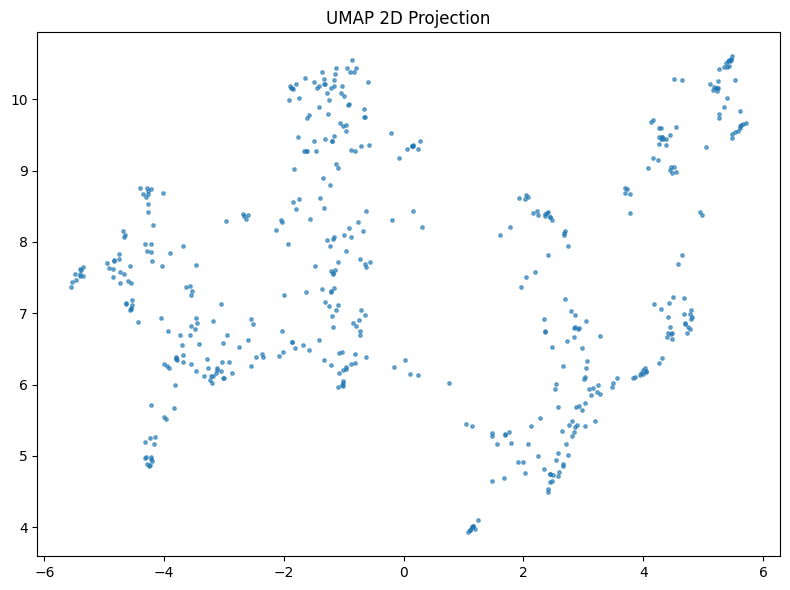

🖼️ Saved: umap_scatter_2d.png


In [57]:
from sklearn.manifold import TSNE
X_tsne = embeddings
if len(X_tsne) > TSNE_MAX_N:
    idx = np.random.RandomState(42).choice(len(X_tsne), TSNE_MAX_N, replace=False)
    X_tsne = X_tsne[idx]
print(f"⏳ t-SNE on {len(X_tsne)} samples ...")
tsne = TSNE(n_components=2, init="pca", random_state=42)
Y_tsne = tsne.fit_transform(X_tsne)
plt.figure(figsize=(8,6))
plt.scatter(Y_tsne[:,0], Y_tsne[:,1], s=6, alpha=0.6)
plt.title("t-SNE 2D Projection")
plt.tight_layout()
plt.savefig("tsne_scatter_2d.png", dpi=160)
plt.show()
print("🖼️ Saved: tsne_scatter_2d.png")

try:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    Y_umap = reducer.fit_transform(embeddings)
    plt.figure(figsize=(8,6))
    plt.scatter(Y_umap[:,0], Y_umap[:,1], s=6, alpha=0.6)
    plt.title("UMAP 2D Projection")
    plt.tight_layout()
    plt.savefig("umap_scatter_2d.png", dpi=160)
    plt.show()
    print("🖼️ Saved: umap_scatter_2d.png")
except ImportError:
    print("ℹ️ Bỏ qua UMAP (chưa cài umap-learn)")